# Benchmark : Naïve vs Cython vs Sklearn

Ce notebook compare **3 implémentations** de Random Forest sur **4 datasets** :

| Version | Fichier | Technique |
|---------|---------|----------|
| **Naïve** | `naive.py` | Python pur, listes, séquentiel |
| **Cython** | `optimised_cython.py` | Fonctions critiques compilées en C |
| **Sklearn** | `sklearn` | Référence industrielle |

**Tâches :**
- **Classification** : 1 dataset synthétique (Moons) + 1 dataset réel (Breast Cancer)
- **Régression** : 1 dataset synthétique (sinusoïde bruitée) + 1 dataset réel (California Housing)

**Métriques :** temps d'entraînement (5 runs), Accuracy/F1 (classif), R²/MAE (regress)

## 1. Compilation Cython

In [1]:
import subprocess, sys, os, time, warnings
warnings.filterwarnings('ignore')

dossier = os.path.dirname(os.path.abspath('__file__'))
os.chdir(dossier)
sys.path.insert(0, dossier)

result = subprocess.run(
    [sys.executable, 'setup.py', 'build_ext', '--inplace'],
    capture_output=True, text=True
)
print('Cython :', 'OK' if result.returncode == 0 else 'ERREUR\n' + result.stderr[-300:])

Cython : OK


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

# Nos implémentations
from naive import RandomForestClassifieurNaif, RandomForestRegresseurNaif
from optimised_cython import RandomForestClassifieurCython, RandomForestRegresseurCython

# Sklearn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    r2_score, mean_absolute_error
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Paramètres globaux
GRAINE  = 42
N_TREES = 20
DEPTH   = 5
N_RUNS  = 5

# Palette de couleurs fixe pour chaque version
COULEURS = {
    'Naïve':  '#e74c3c',
    'Cython': '#e67e22',
    'Sklearn': '#9b59b6'
}

print(f'OK | arbres={N_TREES} | profondeur={DEPTH} | runs={N_RUNS}')

OK | arbres=20 | profondeur=5 | runs=5


## 3. Chargement des 4 datasets

### Datasets de classification
- **Moons (synthétique)** : 600 points, 2 features, frontière non-linéaire — permet de visualiser la frontière de décision
- **Breast Cancer (réel)** : 569 patients, 30 features cellulaires, binaire malin/bénin

### Datasets de régression
- **Sinusoïde bruitée (synthétique)** : y = sin(x) + bruit — idéal pour visualiser les courbes prédites
- **California Housing (réel)** : 20 640 maisons, 8 features, prix médian à prédire

In [3]:
# ---- CLASSIFICATION 1 : Moons (synthétique) ----
X_moons, y_moons = make_moons(n_samples=600, noise=0.25, random_state=GRAINE)
X_moons = X_moons.astype(np.float64)
y_moons = y_moons.astype(np.int64)
Xtr_m, Xte_m, ytr_m, yte_m = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=GRAINE, stratify=y_moons
)

# ---- CLASSIFICATION 2 : Breast Cancer (réel) ----
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float64)
y_bc = bc.target.astype(np.int64)
Xtr_bc, Xte_bc, ytr_bc, yte_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=GRAINE, stratify=y_bc
)

# ---- RÉGRESSION 1 : Sinusoïde bruitée (synthétique) ----
rng = np.random.RandomState(GRAINE)
X_sin = np.sort(rng.uniform(0, 6, 400))[:, None].astype(np.float64)
y_sin = (np.sin(X_sin.ravel()) + rng.normal(0, 0.3, 400)).astype(np.float64)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_sin, y_sin, test_size=0.25, random_state=GRAINE
)

# ---- RÉGRESSION 2 : California Housing (réel) ----
cal = fetch_california_housing()
# On sous-échantillonne à 2000 pour que la version naïve soit raisonnable
idx_cal = rng.choice(len(cal.target), 2000, replace=False)
X_cal = cal.data[idx_cal].astype(np.float64)
y_cal = cal.target[idx_cal].astype(np.float64)
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X_cal, y_cal, test_size=0.25, random_state=GRAINE
)

# Résumé
infos = [
    ('Moons (classif, synth.)',   X_moons.shape, 2,  'binaire'),
    ('Breast Cancer (classif)',   X_bc.shape,    2,  'binaire'),
    ('Sinus (regress, synth.)',   X_sin.shape,   1,  'continue'),
    ('California Housing (reg.)', X_cal.shape,   8,  'continue'),
]
print(f"{'Dataset':<32} {'Shape':>12} {'Features':>9} {'Cible':>10}")
print('-'*68)
for nom, shape, feats, cible in infos:
    print(f"{nom:<32} {str(shape):>12} {feats:>9} {cible:>10}")

Dataset                                 Shape  Features      Cible
--------------------------------------------------------------------
Moons (classif, synth.)              (600, 2)         2    binaire
Breast Cancer (classif)             (569, 30)         2    binaire
Sinus (regress, synth.)              (400, 1)         1   continue
California Housing (reg.)           (2000, 8)         8   continue


## 4. Visualisation des 4 datasets

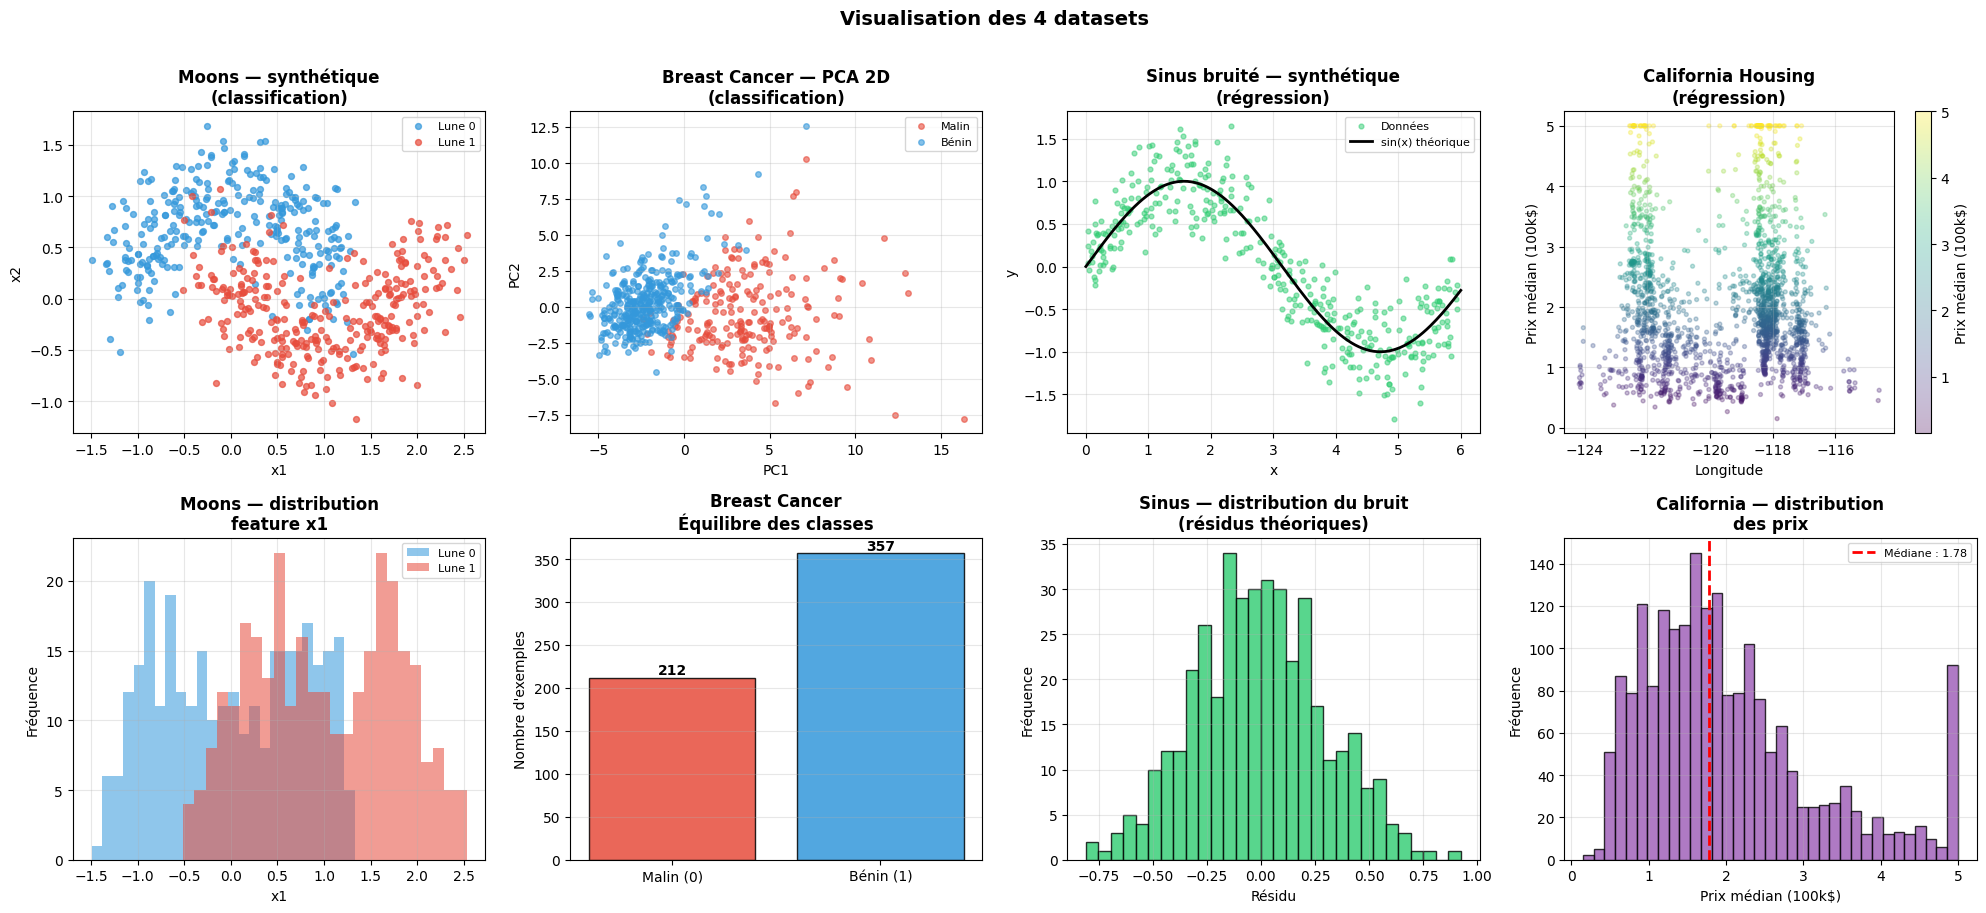

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Visualisation des 4 datasets', fontsize=14, fontweight='bold', y=1.01)

c0, c1 = '#3498db', '#e74c3c'

# ---- Moons : scatter direct ----
ax = axes[0, 0]
for cls, c, label in [(0, c0, 'Lune 0'), (1, c1, 'Lune 1')]:
    m = y_moons == cls
    ax.scatter(X_moons[m, 0], X_moons[m, 1], c=c, s=18, alpha=0.7, label=label)
ax.set_title('Moons — synthétique\n(classification)', fontweight='bold')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ---- Moons : distribution des 2 features ----
ax = axes[1, 0]
for cls, c, label in [(0, c0, 'Lune 0'), (1, c1, 'Lune 1')]:
    m = y_moons == cls
    ax.hist(X_moons[m, 0], bins=25, alpha=0.55, color=c, label=label)
ax.set_title('Moons — distribution\nfeature x1', fontweight='bold')
ax.set_xlabel('x1'); ax.set_ylabel('Fréquence')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ---- Breast Cancer : PCA 2D ----
ax = axes[0, 1]
X_bc_2d = PCA(2, random_state=GRAINE).fit_transform(StandardScaler().fit_transform(X_bc))
for cls, c, label in [(0, c1, 'Malin'), (1, c0, 'Bénin')]:
    m = y_bc == cls
    ax.scatter(X_bc_2d[m, 0], X_bc_2d[m, 1], c=c, s=16, alpha=0.6, label=label)
ax.set_title('Breast Cancer — PCA 2D\n(classification)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ---- Breast Cancer : équilibre des classes ----
ax = axes[1, 1]
counts = np.bincount(y_bc)
bars = ax.bar(['Malin (0)', 'Bénin (1)'], counts, color=[c1, c0],
               edgecolor='black', alpha=0.85)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 4, str(v),
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Breast Cancer\nÉquilibre des classes', fontweight='bold')
ax.set_ylabel('Nombre d\'exemples'); ax.grid(True, alpha=0.3, axis='y')

# ---- Sinusoïde : courbe + bruit ----
ax = axes[0, 2]
ax.scatter(X_sin.ravel(), y_sin, s=12, alpha=0.5, color='#2ecc71', label='Données')
x_plot = np.linspace(0, 6, 200)
ax.plot(x_plot, np.sin(x_plot), color='black', lw=2, label='sin(x) théorique')
ax.set_title('Sinus bruité — synthétique\n(régression)', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ---- Sinusoïde : distribution des résidus ----
ax = axes[1, 2]
residus = y_sin - np.sin(X_sin.ravel())
ax.hist(residus, bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_title('Sinus — distribution du bruit\n(résidus théoriques)', fontweight='bold')
ax.set_xlabel('Résidu'); ax.set_ylabel('Fréquence'); ax.grid(True, alpha=0.3)

# ---- California : scatter prix vs revenu médian ----
ax = axes[0, 3]
sc = ax.scatter(X_cal[:, 7], y_cal, s=8, alpha=0.3,
                c=y_cal, cmap='viridis')
plt.colorbar(sc, ax=ax, label='Prix médian (100k$)')
ax.set_title('California Housing\n(régression)', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Prix médian (100k$)')
ax.grid(True, alpha=0.3)

# ---- California : distribution du prix ----
ax = axes[1, 3]
ax.hist(y_cal, bins=35, color='#9b59b6', edgecolor='black', alpha=0.8)
ax.axvline(np.median(y_cal), color='red', linestyle='--', lw=2,
           label=f'Médiane : {np.median(y_cal):.2f}')
ax.set_title('California — distribution\ndes prix', fontweight='bold')
ax.set_xlabel('Prix médian (100k$)'); ax.set_ylabel('Fréquence')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualisation_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fonctions de benchmark

In [5]:
def benchmark_classif(nom, classe, X_train, y_train, X_test, y_test, kwargs, n_runs=N_RUNS):
    """
    Mesure le temps d'entraînement sur n_runs répétitions pour un classifieur.
    Retourne : dict avec temps_moy, temps_std, accuracy, f1, tous_les_temps.
    """
    temps = []
    modele = None
    for _ in range(n_runs):
        modele = classe(**kwargs)
        t0 = time.perf_counter()
        modele.fit(X_train, y_train)
        temps.append(time.perf_counter() - t0)
    preds = np.array(modele.predict(X_test))
    return {
        'modele':     nom,
        'temps_moy':  np.mean(temps),
        'temps_std':  np.std(temps),
        'accuracy':   accuracy_score(y_test, preds),
        'f1':         f1_score(y_test, preds, average='binary'),
        'temps_list': temps,
        'preds':      preds,
    }


def benchmark_regress(nom, classe, X_train, y_train, X_test, y_test, kwargs, n_runs=N_RUNS):
    """
    Mesure le temps d'entraînement sur n_runs répétitions pour un régresseur.
    Retourne : dict avec temps_moy, temps_std, r2, mae, tous_les_temps.
    """
    temps = []
    modele = None
    for _ in range(n_runs):
        modele = classe(**kwargs)
        t0 = time.perf_counter()
        modele.fit(X_train, y_train)
        temps.append(time.perf_counter() - t0)
    preds = np.array(modele.predict(X_test))
    return {
        'modele':     nom,
        'temps_moy':  np.mean(temps),
        'temps_std':  np.std(temps),
        'r2':         r2_score(y_test, preds),
        'mae':        mean_absolute_error(y_test, preds),
        'temps_list': temps,
        'preds':      preds,
    }


print('Fonctions de benchmark définies.')

Fonctions de benchmark définies.


## 6. Benchmark — Classification

In [6]:
kw_base = {'n_arbres': N_TREES, 'profondeur_max': DEPTH, 'graine': GRAINE}
kw_sk_c = {'n_estimators': N_TREES, 'max_depth': DEPTH, 'random_state': GRAINE, 'n_jobs': 1}

# ---- Moons ----
print('=== Classification : Moons ===')
res_c_moons = [
    benchmark_classif('Naïve',  RandomForestClassifieurNaif,
                      Xtr_m.tolist(), ytr_m.tolist(), Xte_m.tolist(), yte_m.tolist(), kw_base),
    benchmark_classif('Cython', RandomForestClassifieurCython,
                      Xtr_m, ytr_m, Xte_m, yte_m, kw_base),
]
# Sklearn
sk_m = RandomForestClassifier(**kw_sk_c)
temps_sk_m = []
for _ in range(N_RUNS):
    t0 = time.perf_counter(); sk_m.fit(Xtr_m, ytr_m); temps_sk_m.append(time.perf_counter()-t0)
res_c_moons.append({'modele':'Sklearn','temps_moy':np.mean(temps_sk_m),'temps_std':np.std(temps_sk_m),
                    'accuracy':sk_m.score(Xte_m,yte_m),'f1':f1_score(yte_m,sk_m.predict(Xte_m)),
                    'temps_list':temps_sk_m,'preds':sk_m.predict(Xte_m)})

for r in res_c_moons:
    print(f"  {r['modele']:<10} {r['temps_moy']:.4f}s ± {r['temps_std']:.4f}s | "
          f"Acc={r['accuracy']:.3f} F1={r['f1']:.3f}")

# ---- Breast Cancer ----
print('\n=== Classification : Breast Cancer ===')
res_c_bc = [
    benchmark_classif('Naïve',  RandomForestClassifieurNaif,
                      Xtr_bc.tolist(), ytr_bc.tolist(), Xte_bc.tolist(), yte_bc.tolist(), kw_base),
    benchmark_classif('Cython', RandomForestClassifieurCython,
                      Xtr_bc, ytr_bc, Xte_bc, yte_bc, kw_base),
]
sk_bc = RandomForestClassifier(**kw_sk_c)
temps_sk_bc = []
for _ in range(N_RUNS):
    t0 = time.perf_counter(); sk_bc.fit(Xtr_bc, ytr_bc); temps_sk_bc.append(time.perf_counter()-t0)
res_c_bc.append({'modele':'Sklearn','temps_moy':np.mean(temps_sk_bc),'temps_std':np.std(temps_sk_bc),
                 'accuracy':sk_bc.score(Xte_bc,yte_bc),'f1':f1_score(yte_bc,sk_bc.predict(Xte_bc)),
                 'temps_list':temps_sk_bc,'preds':sk_bc.predict(Xte_bc)})

for r in res_c_bc:
    print(f"  {r['modele']:<10} {r['temps_moy']:.4f}s ± {r['temps_std']:.4f}s | "
          f"Acc={r['accuracy']:.3f} F1={r['f1']:.3f}")

=== Classification : Moons ===
  Naïve      0.6064s ± 0.0467s | Acc=0.887 F1=0.889
  Cython     0.0827s ± 0.1150s | Acc=0.913 F1=0.914
  Sklearn    0.0115s ± 0.0006s | Acc=0.920 F1=0.919

=== Classification : Breast Cancer ===
  Naïve      2.7662s ± 0.0820s | Acc=0.951 F1=0.961
  Cython     0.1016s ± 0.0225s | Acc=0.958 F1=0.967
  Sklearn    0.0197s ± 0.0022s | Acc=0.951 F1=0.961


## 7. Benchmark — Régression

In [7]:
kw_sk_r = {'n_estimators': N_TREES, 'max_depth': DEPTH, 'random_state': GRAINE, 'n_jobs': 1}

# ---- Sinusoïde ----
print('=== Régression : Sinusoïde ===')
res_r_sin = [
    benchmark_regress('Naïve',  RandomForestRegresseurNaif,
                      Xtr_s.tolist(), ytr_s.tolist(), Xte_s.tolist(), yte_s.tolist(), kw_base),
    benchmark_regress('Cython', RandomForestRegresseurCython,
                      Xtr_s, ytr_s, Xte_s, yte_s, kw_base),
]
sk_s = RandomForestRegressor(**kw_sk_r)
temps_sk_s = []
for _ in range(N_RUNS):
    t0 = time.perf_counter(); sk_s.fit(Xtr_s, ytr_s); temps_sk_s.append(time.perf_counter()-t0)
preds_sk_s = sk_s.predict(Xte_s)
res_r_sin.append({'modele':'Sklearn','temps_moy':np.mean(temps_sk_s),'temps_std':np.std(temps_sk_s),
                  'r2':r2_score(yte_s,preds_sk_s),'mae':mean_absolute_error(yte_s,preds_sk_s),
                  'temps_list':temps_sk_s,'preds':preds_sk_s})

for r in res_r_sin:
    print(f"  {r['modele']:<10} {r['temps_moy']:.4f}s ± {r['temps_std']:.4f}s | "
          f"R²={r['r2']:.3f} MAE={r['mae']:.3f}")

# ---- California ----
print('\n=== Régression : California Housing ===')
res_r_cal = [
    benchmark_regress('Naïve',  RandomForestRegresseurNaif,
                      Xtr_c.tolist(), ytr_c.tolist(), Xte_c.tolist(), yte_c.tolist(), kw_base),
    benchmark_regress('Cython', RandomForestRegresseurCython,
                      Xtr_c, ytr_c, Xte_c, yte_c, kw_base),
]
sk_c = RandomForestRegressor(**kw_sk_r)
temps_sk_c = []
for _ in range(N_RUNS):
    t0 = time.perf_counter(); sk_c.fit(Xtr_c, ytr_c); temps_sk_c.append(time.perf_counter()-t0)
preds_sk_c = sk_c.predict(Xte_c)
res_r_cal.append({'modele':'Sklearn','temps_moy':np.mean(temps_sk_c),'temps_std':np.std(temps_sk_c),
                  'r2':r2_score(yte_c,preds_sk_c),'mae':mean_absolute_error(yte_c,preds_sk_c),
                  'temps_list':temps_sk_c,'preds':preds_sk_c})

for r in res_r_cal:
    print(f"  {r['modele']:<10} {r['temps_moy']:.4f}s ± {r['temps_std']:.4f}s | "
          f"R²={r['r2']:.3f} MAE={r['mae']:.3f}")

=== Régression : Sinusoïde ===
  Naïve      0.3891s ± 0.0045s | R²=0.834 MAE=0.234
  Cython     0.0254s ± 0.0011s | R²=0.828 MAE=0.241
  Sklearn    0.0095s ± 0.0007s | R²=0.840 MAE=0.226

=== Régression : California Housing ===
  Naïve      14.8721s ± 0.1291s | R²=0.628 MAE=0.485
  Cython     0.1216s ± 0.0055s | R²=0.621 MAE=0.490
  Sklearn    0.0428s ± 0.0003s | R²=0.657 MAE=0.458


## 8. Visualisation des résultats — Classification

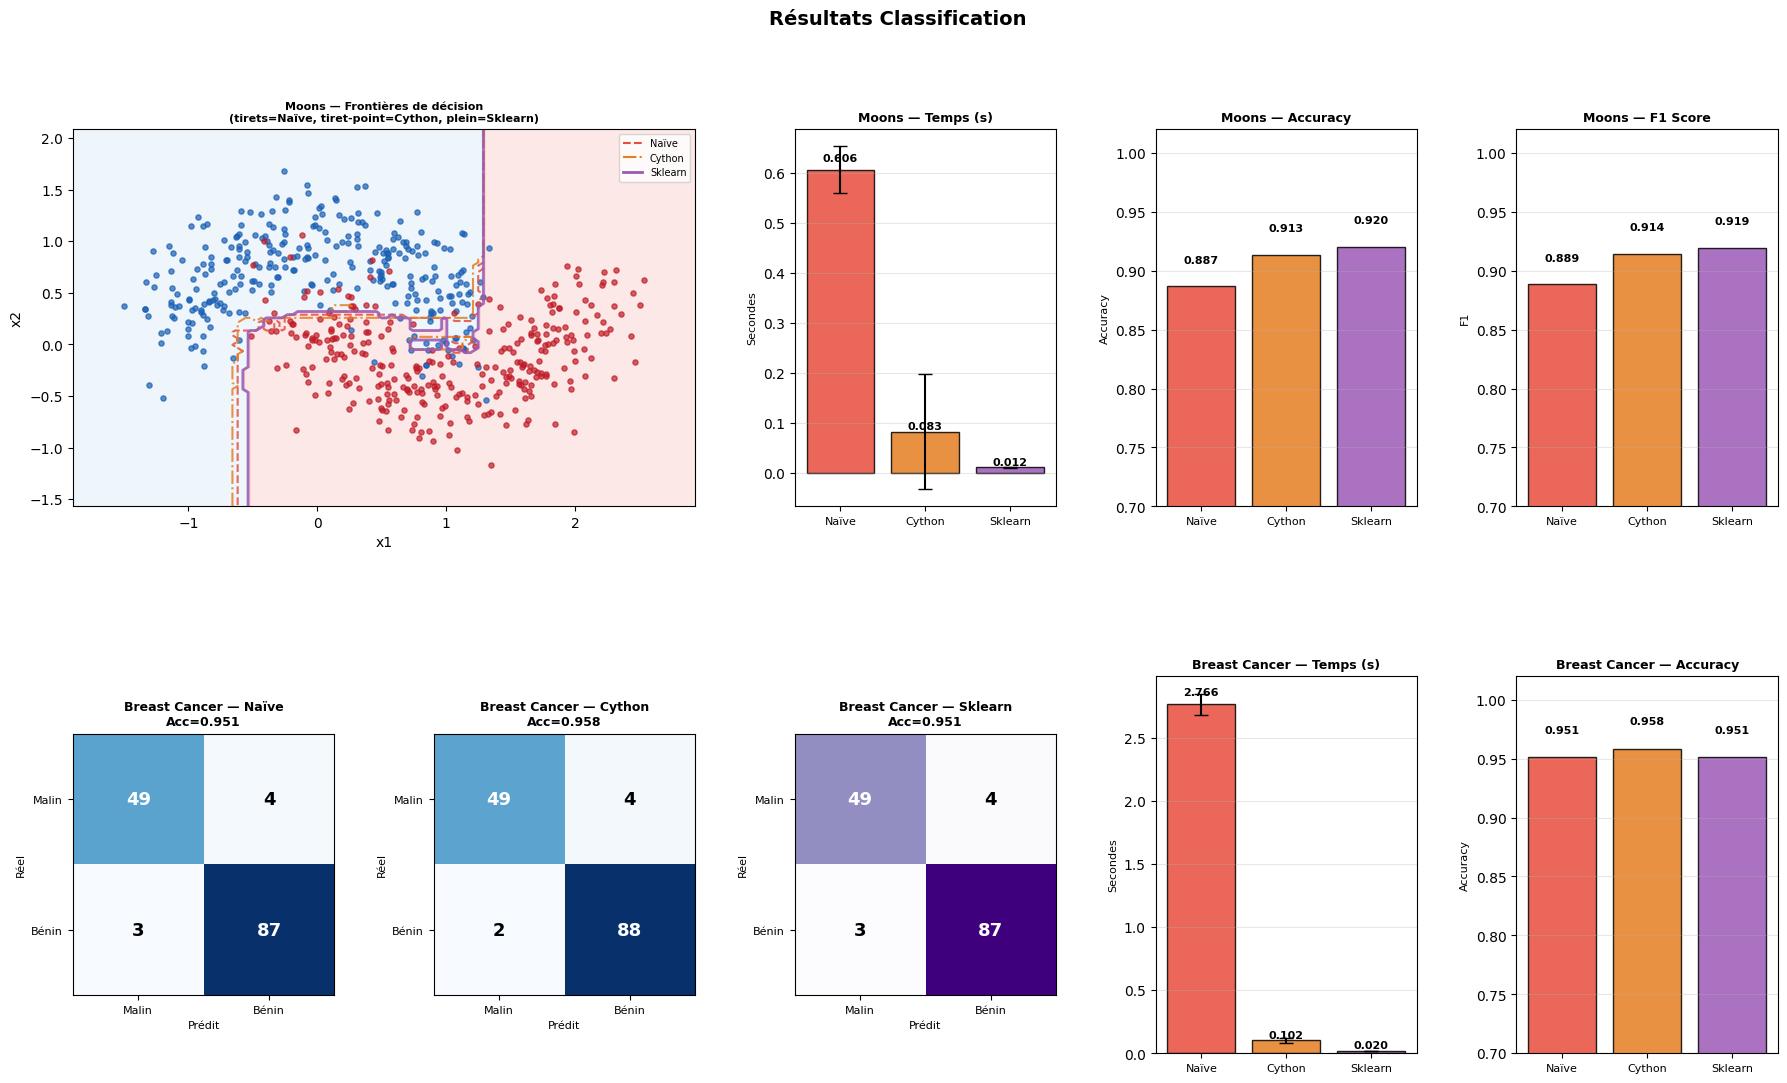

Sauvegardé : resultats_classification.png


In [8]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Résultats Classification', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.38)

modeles_ordre = ['Naïve', 'Cython', 'Sklearn']

def plot_barres(ax, resultats, metrique, titre, ylabel, ylim=None):
    """Trace des barres avec barres d'erreur pour les temps, ou barres simples pour les métriques."""
    noms  = [r['modele'] for r in resultats]
    vals  = [r[metrique] for r in resultats]
    bars  = ax.bar(noms, vals, color=[COULEURS[n] for n in noms],
                   edgecolor='black', alpha=0.85)
    if metrique == 'temps_moy':
        errs = [r['temps_std'] for r in resultats]
        ax.errorbar(noms, vals, yerr=errs, fmt='none', color='black', capsize=5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v*1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(titre, fontweight='bold', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=8)
    if ylim: ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=8)

# --- Ligne 1 : Moons ---
# Frontières de décision
ax_fd = fig.add_subplot(gs[0, 0:2])
x_min, x_max = X_moons[:,0].min()-0.4, X_moons[:,0].max()+0.4
y_min, y_max = X_moons[:,1].min()-0.4, X_moons[:,1].max()+0.4
xx, yy = np.meshgrid(np.linspace(x_min,x_max,120), np.linspace(y_min,y_max,120))
grille = np.c_[xx.ravel(), yy.ravel()]
cmap_bg = ListedColormap(['#aed6f1','#f1948a'])

# On superpose les 3 frontières : Naïve (pointillés), Cython (tirets), Sklearn (plein)
for res, lw, ls, label in [
    (res_c_moons[0], 1.5, '--',  'Naïve'),
    (res_c_moons[1], 1.5, '-.',  'Cython'),
    (res_c_moons[2], 2.0, '-',   'Sklearn'),
]:
    if res['modele'] == 'Naïve':
        m = RandomForestClassifieurNaif(**kw_base)
        m.fit(Xtr_m.tolist(), ytr_m.tolist())
        Z = np.array(m.predict(grille.tolist())).reshape(xx.shape)
    elif res['modele'] == 'Cython':
        m = RandomForestClassifieurCython(**kw_base)
        m.fit(Xtr_m, ytr_m)
        Z = np.array(m.predict(grille)).reshape(xx.shape)
    else:
        m = RandomForestClassifier(**kw_sk_c)
        m.fit(Xtr_m, ytr_m)
        Z = m.predict(grille).reshape(xx.shape)
    ax_fd.contour(xx, yy, Z, colors=[COULEURS[res['modele']]], linewidths=lw, linestyles=ls,
                  levels=[0.5], alpha=0.85)

# Fond sklearn
ax_fd.contourf(xx, yy, m.predict(grille).reshape(xx.shape), alpha=0.2, cmap=cmap_bg)
for cls, c in [(0,'#1a5fb4'),(1,'#c01c28')]:
    mask = y_moons == cls
    ax_fd.scatter(X_moons[mask,0], X_moons[mask,1], c=c, s=14, alpha=0.7)
ax_fd.set_title('Moons — Frontières de décision\n(tirets=Naïve, tiret-point=Cython, plein=Sklearn)',
                fontweight='bold', fontsize=8)
ax_fd.set_xlabel('x1'); ax_fd.set_ylabel('x2')
# Légende manuelle
from matplotlib.lines import Line2D
ax_fd.legend(handles=[
    Line2D([0],[0],color=COULEURS['Naïve'], lw=1.5, ls='--', label='Naïve'),
    Line2D([0],[0],color=COULEURS['Cython'], lw=1.5, ls='-.', label='Cython'),
    Line2D([0],[0],color=COULEURS['Sklearn'], lw=2, ls='-', label='Sklearn'),
], fontsize=7, loc='upper right')

# Temps Moons
plot_barres(fig.add_subplot(gs[0, 2]), res_c_moons, 'temps_moy',
            'Moons — Temps (s)', 'Secondes')
# Accuracy Moons
plot_barres(fig.add_subplot(gs[0, 3]), res_c_moons, 'accuracy',
            'Moons — Accuracy', 'Accuracy', ylim=(0.7, 1.02))
# F1 Moons
plot_barres(fig.add_subplot(gs[0, 4]), res_c_moons, 'f1',
            'Moons — F1 Score', 'F1', ylim=(0.7, 1.02))

# --- Ligne 2 : Breast Cancer ---
# Matrices de confusion (3 côte à côte)
for col, res in enumerate(res_c_bc):
    ax = fig.add_subplot(gs[1, col])
    cm = confusion_matrix(yte_bc, res['preds'])
    cmap_cm = 'Blues' if res['modele'] != 'Sklearn' else 'Purples'
    ax.imshow(cm, cmap=cmap_cm)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Malin','Bénin'], fontsize=8)
    ax.set_yticklabels(['Malin','Bénin'], fontsize=8)
    ax.set_xlabel('Prédit', fontsize=8); ax.set_ylabel('Réel', fontsize=8)
    ax.set_title(f'Breast Cancer — {res["modele"]}\nAcc={res["accuracy"]:.3f}',
                 fontweight='bold', fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black')

# Temps Breast Cancer
plot_barres(fig.add_subplot(gs[1, 3]), res_c_bc, 'temps_moy',
            'Breast Cancer — Temps (s)', 'Secondes')
# Accuracy Breast Cancer
plot_barres(fig.add_subplot(gs[1, 4]), res_c_bc, 'accuracy',
            'Breast Cancer — Accuracy', 'Accuracy', ylim=(0.7, 1.02))

plt.savefig('resultats_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : resultats_classification.png')

## 9. Visualisation des résultats — Régression

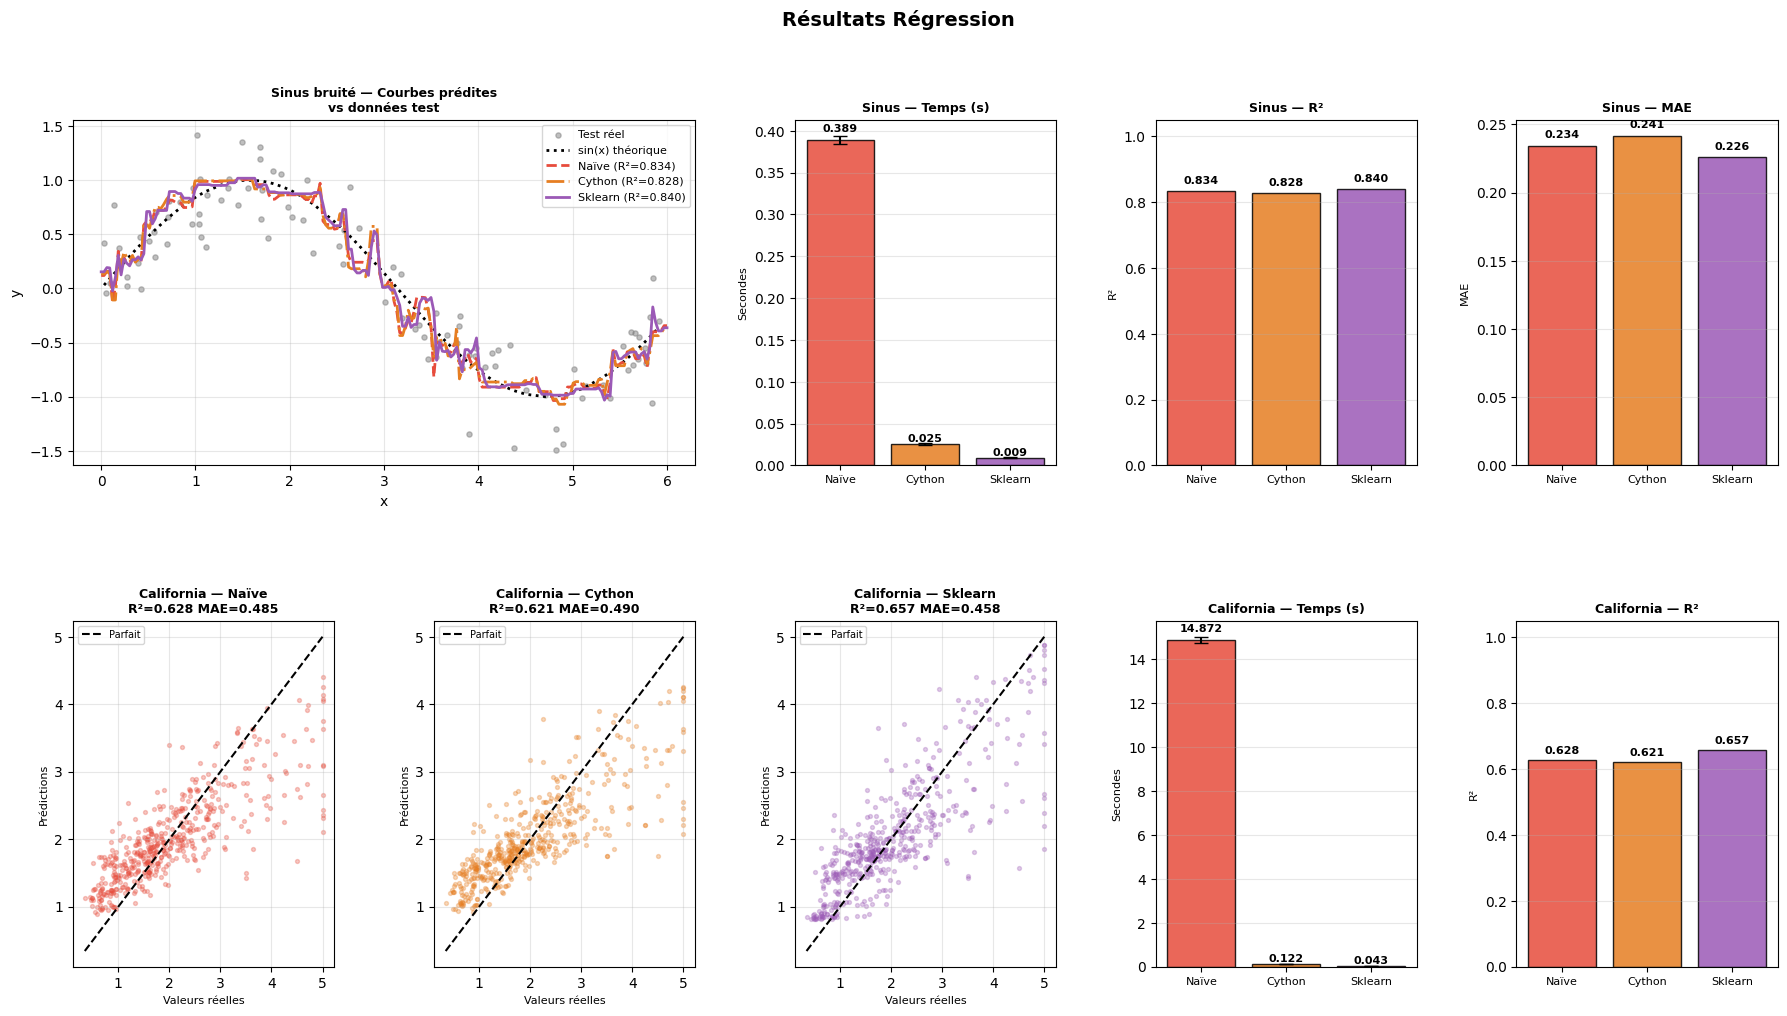

Sauvegardé : resultats_regression.png


In [9]:
fig = plt.figure(figsize=(22, 11))
fig.suptitle('Résultats Régression', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.38)

# --- Ligne 1 : Sinusoïde ---
# Courbes prédites
ax_sin = fig.add_subplot(gs[0, 0:2])
x_sorted = np.sort(Xte_s.ravel())
ax_sin.scatter(Xte_s.ravel(), yte_s, s=14, alpha=0.5, color='gray', zorder=1, label='Test réel')
ax_sin.plot(x_sorted, np.sin(x_sorted), color='black', lw=2, ls=':', zorder=2, label='sin(x) théorique')

for res, ls, zorder in [(res_r_sin[0], '--', 3), (res_r_sin[1], '-.', 4), (res_r_sin[2], '-', 5)]:
    # Prédire sur une grille régulière pour une courbe lisse
    x_grid = np.linspace(0, 6, 200)[:, None].astype(np.float64)
    if res['modele'] == 'Naïve':
        m = RandomForestRegresseurNaif(**kw_base); m.fit(Xtr_s.tolist(), ytr_s.tolist())
        y_grid = m.predict(x_grid.tolist())
    elif res['modele'] == 'Cython':
        m = RandomForestRegresseurCython(**kw_base); m.fit(Xtr_s, ytr_s)
        y_grid = m.predict(x_grid)
    else:
        m = RandomForestRegressor(**kw_sk_r); m.fit(Xtr_s, ytr_s)
        y_grid = m.predict(x_grid)
    ax_sin.plot(x_grid.ravel(), y_grid, color=COULEURS[res['modele']],
                lw=2, ls=ls, zorder=zorder,
                label=f"{res['modele']} (R²={res['r2']:.3f})")

ax_sin.set_title('Sinus bruité — Courbes prédites\nvs données test', fontweight='bold', fontsize=9)
ax_sin.set_xlabel('x'); ax_sin.set_ylabel('y')
ax_sin.legend(fontsize=8); ax_sin.grid(True, alpha=0.3)

# Temps Sinus
plot_barres(fig.add_subplot(gs[0, 2]), res_r_sin, 'temps_moy',
            'Sinus — Temps (s)', 'Secondes')
# R² Sinus
plot_barres(fig.add_subplot(gs[0, 3]), res_r_sin, 'r2',
            'Sinus — R²', 'R²', ylim=(0, 1.05))
# MAE Sinus
plot_barres(fig.add_subplot(gs[0, 4]), res_r_sin, 'mae',
            'Sinus — MAE', 'MAE')

# --- Ligne 2 : California Housing ---
# Scatter prédit vs réel pour les 3 versions
for col, res in enumerate(res_r_cal):
    ax = fig.add_subplot(gs[1, col])
    ax.scatter(yte_c, res['preds'], s=8, alpha=0.3, color=COULEURS[res['modele']])
    vmin = min(yte_c.min(), res['preds'].min())
    vmax = max(yte_c.max(), res['preds'].max())
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, label='Parfait')
    ax.set_xlabel('Valeurs réelles', fontsize=8)
    ax.set_ylabel('Prédictions', fontsize=8)
    ax.set_title(f'California — {res["modele"]}\nR²={res["r2"]:.3f} MAE={res["mae"]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Temps California
plot_barres(fig.add_subplot(gs[1, 3]), res_r_cal, 'temps_moy',
            'California — Temps (s)', 'Secondes')
# R² California
plot_barres(fig.add_subplot(gs[1, 4]), res_r_cal, 'r2',
            'California — R²', 'R²', ylim=(0, 1.05))

plt.savefig('resultats_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : resultats_regression.png')

## 10. Speedup Cython vs Naïve — tableau et graphique

=== Speedup vs Naïve ===
  Classification — Moons
    Naïve      0.6064s  → speedup 1.0×
    Cython     0.0827s  → speedup 7.3×
    Sklearn    0.0115s  → speedup 52.5×
  Classification — Breast Cancer
    Naïve      2.7662s  → speedup 1.0×
    Cython     0.1016s  → speedup 27.2×
    Sklearn    0.0197s  → speedup 140.5×
  Régression — Sinus
    Naïve      0.3891s  → speedup 1.0×
    Cython     0.0254s  → speedup 15.3×
    Sklearn    0.0095s  → speedup 41.1×
  Régression — California
    Naïve      14.8721s  → speedup 1.0×
    Cython     0.1216s  → speedup 122.3×
    Sklearn    0.0428s  → speedup 347.3×


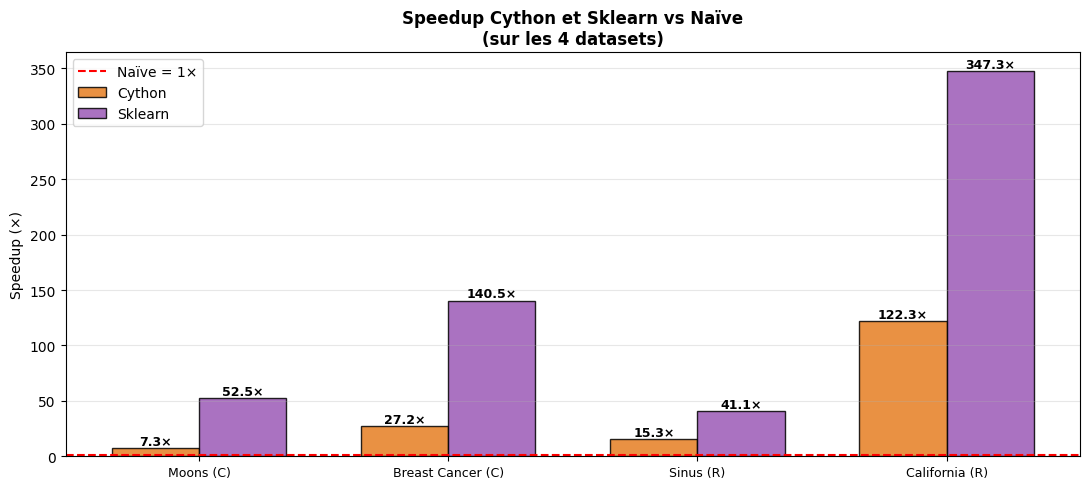

In [10]:
def speedup_tableau(resultats, nom_dataset):
    """Calcule et affiche le speedup de chaque version vs Naïve."""
    t_naive = next(r['temps_moy'] for r in resultats if r['modele'] == 'Naïve')
    print(f"  {nom_dataset}")
    for r in resultats:
        sp = t_naive / r['temps_moy']
        print(f"    {r['modele']:<10} {r['temps_moy']:.4f}s  → speedup {sp:.1f}×")

print('=== Speedup vs Naïve ===')
speedup_tableau(res_c_moons, 'Classification — Moons')
speedup_tableau(res_c_bc,    'Classification — Breast Cancer')
speedup_tableau(res_r_sin,   'Régression — Sinus')
speedup_tableau(res_r_cal,   'Régression — California')

# Graphique résumé des speedups
datasets_noms   = ['Moons (C)', 'Breast Cancer (C)', 'Sinus (R)', 'California (R)']
tous_resultats  = [res_c_moons, res_c_bc, res_r_sin, res_r_cal]
speedups_cython = []
speedups_sklearn = []

for res in tous_resultats:
    t_n = next(r['temps_moy'] for r in res if r['modele'] == 'Naïve')
    t_c = next(r['temps_moy'] for r in res if r['modele'] == 'Cython')
    t_s = next(r['temps_moy'] for r in res if r['modele'] == 'Sklearn')
    speedups_cython.append(t_n / t_c)
    speedups_sklearn.append(t_n / t_s)

x = np.arange(len(datasets_noms))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, speedups_cython,  width, label='Cython',  color=COULEURS['Cython'],  edgecolor='black', alpha=0.85)
b2 = ax.bar(x + width/2, speedups_sklearn, width, label='Sklearn', color=COULEURS['Sklearn'], edgecolor='black', alpha=0.85)

for bar, v in list(zip(b1, speedups_cython)) + list(zip(b2, speedups_sklearn)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(1, color='red', linestyle='--', lw=1.5, label='Naïve = 1×')
ax.set_xticks(x); ax.set_xticklabels(datasets_noms, fontsize=9)
ax.set_ylabel('Speedup (×)')
ax.set_title('Speedup Cython et Sklearn vs Naïve\n(sur les 4 datasets)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('speedup_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Boxplot — variabilité des temps (5 runs)

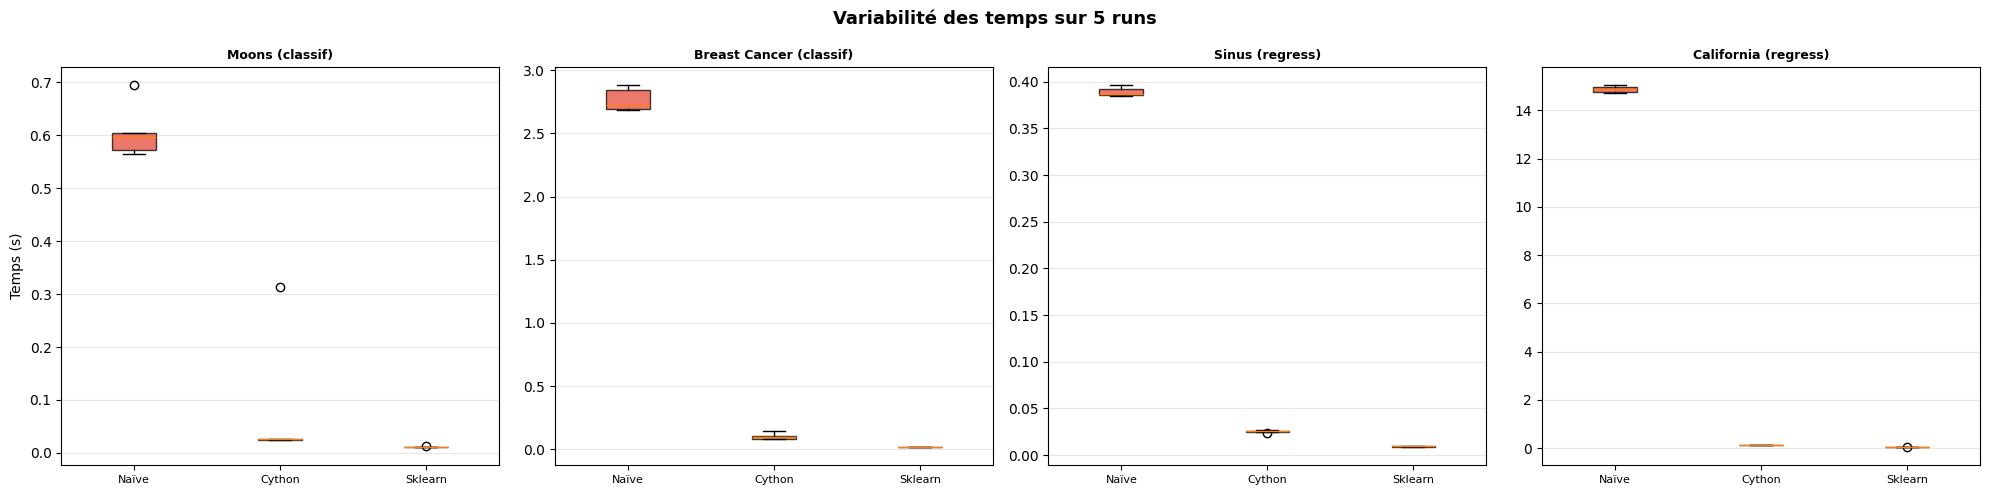

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Variabilité des temps sur {N_RUNS} runs', fontsize=13, fontweight='bold')

for ax, res, titre in zip(
    axes,
    [res_c_moons, res_c_bc, res_r_sin, res_r_cal],
    ['Moons (classif)', 'Breast Cancer (classif)', 'Sinus (regress)', 'California (regress)']
):
    donnees = [r['temps_list'] for r in res]
    labels  = [r['modele'] for r in res]
    bp = ax.boxplot(donnees, labels=labels, patch_artist=True)
    for patch, nom in zip(bp['boxes'], labels):
        patch.set_facecolor(COULEURS[nom])
        patch.set_alpha(0.75)
    ax.set_title(titre, fontweight='bold', fontsize=9)
    ax.set_ylabel('Temps (s)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_variabilite.png', dpi=150, bbox_inches='tight')
plt.show()